In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pvlib
from pvlib.pvsystem import PVSystem
from pvlib.location import Location
from pvlib.modelchain import ModelChain
import json
import s3fs

In [71]:
def listDataFiles(dirName):
    fs = s3fs.S3FileSystem(anon=True)
    files = fs.find(dirName)
    
    for file in files:
        print(file)

In [72]:
def openDataFile(fileName):
    df = pd.read_csv(fileName, storage_options={'anon': True})
    
    # Display the first few rows
    print(df.head())
    return df

In [73]:
def openMetadataFile(fileName):
    fs = s3fs.S3FileSystem(anon=True)
    
    with fs.open(fileName, 'r') as f:
        metadata = json.load(f)
        
    return metadata

In [74]:
json_fileName = "oedi-data-lake/pvdaq/2023-solar-data-prize/2107_OEDI/metadata/2107_system_metadata.json" 
system_info = openMetadataFile(json_fileName)

In [75]:
print("--- SITE INFO (For pvlib Location) ---")
print(json.dumps(system_info['Site'], indent=4))

print("\n--- MOUNT INFO (For pvlib PVSystem) ---")
print(json.dumps(system_info['Mount'], indent=4))

print("\n--- MODULE INFO (For Hardware) ---")
print(json.dumps(system_info['Modules'], indent=4))

--- SITE INFO (For pvlib Location) ---
{
    "site_id": 7211,
    "public_name": "FSA_1",
    "location": "Arbuckle, CA",
    "us_region": "West",
    "latitude": 38.996306,
    "longitude": -122.134111,
    "elevation(m)": 10.0,
    "climate_type": "Csa"
}

--- MOUNT INFO (For pvlib PVSystem) ---
{
    "Mount 0": {
        "mount_id": 17263,
        "name": "mnt_fss_1",
        "manufacturer": "Schletter",
        "model": "",
        "tracking": "f",
        "type": "ground",
        "azimuth": 180.0,
        "tilt": 25.0
    }
}

--- MODULE INFO (For Hardware) ---
{
    "Module 0": {
        "module_id": 55773,
        "inverter_id": "None",
        "name": "mod_fss_1",
        "manufacturer": "Hyundai",
        "model": "HiS-M310TI",
        "type": "mono-Si",
        "quantity": 120,
        "start_on": "2017-11-01 00:00:00",
        "end_on": "",
        "serial_num": "",
        "reference_module": "False",
        "comments": ""
    },
    "Module 1": {
        "module_id": 557

In [76]:
base_url = "s3://oedi-data-lake/pvdaq/2023-solar-data-prize/2107_OEDI/data/"
file_irr = base_url + "2107_irradiance_data_2024.csv"
file_env = base_url + "2107_environment_data_2024.csv"
file_meter = base_url + "2107_meter_15m_data_2024.csv"

In [79]:
df_irr = openDataFile(file_irr) #irraadiance data
df_env = openDataFile(file_env) #local weather data
df_meter = openDataFile(file_meter) #ac output

           measured_on  poa_irradiance_o_149574
0  2024-01-01 00:10:00                      0.0
1  2024-01-01 00:15:00                      0.0
2  2024-01-01 00:25:00                      0.0
3  2024-01-01 00:40:00                      0.0
4  2024-01-01 00:45:00                      0.0
           measured_on  ambient_temperature_o_149575  wind_speed_o_149576  \
0  2024-01-01 00:15:00                          44.2                  3.3   
1  2024-01-01 00:30:00                          44.2                  3.3   
2  2024-01-01 00:45:00                          44.2                  3.3   
3  2024-01-01 01:00:00                          43.9                  2.3   
4  2024-01-01 01:15:00                          43.9                  2.3   

   wind_direction_o_149577  
0                    187.0  
1                    187.0  
2                    187.0  
3                    183.0  
4                    183.0  
           measured_on  meter_revenue_grade_ac_output_meter_149578
0  2024-

In [80]:
#need to do some sort of time zone fixing
for df in [df_irr, df_env, df_meter]:
    df['measured_on'] = pd.to_datetime(df['measured_on'])
    df.set_index('measured_on', inplace=True)
    
    if df.index.tz is None:
        df.index = df.index.tz_localize('UTC')
    df.index = df.index.tz_convert('America/Los_Angeles')

In [82]:
#we do 15 minute resampling since we have 15 minute data intervals
df_irr_resampled = df_irr.resample('15min').mean()
df_env_resampled = df_env.resample('15min').mean()
df_meter_resampled = df_meter.resample('15min').mean()

In [83]:
#merge into one big dataframe
df_master = pd.concat([df_irr_resampled, df_env_resampled, df_meter_resampled], axis=1)

In [85]:
#fill in gaps of data with previous value if there are gaps <= 30 minutes 
df_master = df_master.ffill(limit=2) 

#drop away rows with no solar data
df_master = df_master.dropna(subset=['poa_irradiance_o_149574']) 

In [86]:
df_master

,poa_irradiance_o_149574,ambient_temperature_o_149575,wind_speed_o_149576,wind_direction_o_149577,meter_revenue_grade_ac_output_meter_149578
measured_on,,,,,
2023-12-31 16:00:00-08:00,0.0,NaN,NaN,NaN,NaN
2023-12-31 16:15:00-08:00,0.0,44.2,3.3,187.0,0.0
2023-12-31 16:30:00-08:00,0.0,44.2,3.3,187.0,0.0
2023-12-31 16:45:00-08:00,0.0,44.2,3.3,187.0,0.0
2023-12-31 17:00:00-08:00,0.0,43.9,2.3,183.0,0.0
...,...,...,...,...,...
2024-11-01 16:15:00-07:00,0.0,54.3,11.7,99.0,0.0
2024-11-01 16:30:00-07:00,0.0,54.3,11.7,99.0,0.0
2024-11-01 16:45:00-07:00,0.0,54.3,11.7,99.0,0.0


In [87]:
#drop rows with NaNs to get cleaner data and see how many rows we lost
print(df_master.isna().sum())
rows_before = len(df_master)
df_master = df_master.dropna()
rows_after = len(df_master)
rows_dropped = rows_before - rows_after

print(f"\nTotal rows removed: {rows_dropped}")
print(f"Total rows remaining: {rows_after}")

poa_irradiance_o_149574                       0
ambient_temperature_o_149575                  5
wind_speed_o_149576                           1
wind_direction_o_149577                       1
meter_revenue_grade_ac_output_meter_149578    1
dtype: int64

Total rows removed: 5
Total rows remaining: 29179


In [88]:
df_master.columns.tolist()

['poa_irradiance_o_149574',
 'ambient_temperature_o_149575',
 'wind_speed_o_149576',
 'wind_direction_o_149577',
 'meter_revenue_grade_ac_output_meter_149578']

In [89]:
#rename column names to what pvlib wants to make predictions
rename_map = {
    'poa_irradiance_o_149574': 'poa_global',
    'ambient_temperature_o_149575': 'temp_air',
    'wind_speed_o_149576': 'wind_speed_mph', # Temporary name before conversion
    'meter_revenue_grade_ac_output_meter_149578': 'actual_power_kw'
}
df_master = df_master.rename(columns=rename_map)

In [90]:
#have to convert wind speed to meters per secend from mph
df_master['wind_speed'] = df_master['wind_speed_mph'] / 2.237

#need in watts instead of kilowats for pvlib
df_master['actual_power_w'] = df_master['actual_power_kw'] * 1000

model_df = df_master[['poa_global', 'temp_air', 'wind_speed', 'actual_power_w']].copy()

print(model_df)

                           poa_global  temp_air  wind_speed  actual_power_w
measured_on                                                                
2023-12-31 16:15:00-08:00         0.0      44.2    1.475190             0.0
2023-12-31 16:30:00-08:00         0.0      44.2    1.475190             0.0
2023-12-31 16:45:00-08:00         0.0      44.2    1.475190             0.0
2023-12-31 17:00:00-08:00         0.0      43.9    1.028163             0.0
2023-12-31 17:15:00-08:00         0.0      43.9    1.028163             0.0
...                               ...       ...         ...             ...
2024-11-01 16:15:00-07:00         0.0      54.3    5.230219             0.0
2024-11-01 16:30:00-07:00         0.0      54.3    5.230219             0.0
2024-11-01 16:45:00-07:00         0.0      54.3    5.230219             0.0
2024-11-01 17:00:00-07:00         0.0      54.1    5.230219             0.0
2024-11-01 17:15:00-07:00         0.0      54.1    5.230219             0.0

[29179 rows

In [97]:
#have to rename a column for pvlib
model_df = model_df.rename(columns={'poa_global': 'effective_irradiance'})

In [98]:
model_df.columns

Index(['effective_irradiance', 'temp_air', 'wind_speed', 'actual_power_w'], dtype='str')

In [103]:
#now to make predictions we can use pvlib as shown last time.

#location data + time zone
lat = 38.996306
lon = -122.134111
tz = 'America/Los_Angeles' 

location = Location(latitude=lat, longitude=lon, tz=tz, name='Arbuckle Farm')

#put in system information. note: this is for just *one* panel
system = PVSystem(
    surface_tilt=25.0, 
    surface_azimuth=180.0,
    module_parameters=panel,
    inverter_parameters=inverter,
    temperature_model_parameters=temp_params,
)

#make the model in pvlib
mc = ModelChain(system, location, aoi_model='no_loss', spectral_model='no_loss')

#run a prediction
mc.run_model_from_effective_irradiance(model_df)

#nrel data does not come with what inverter is used, so we make some assumption here that the dc-to-ac is 96% efficient
predicted_dc_power = mc.results.dc['p_mp']
inverter_efficiency = 0.96
total_panels = 2760

#the predicted power is the DC power generated times the efficiency of the inverter times the number of panels
predicted_power_W = predicted_dc_power * inverter_efficiency * total_panels

actual_power_W = model_df['actual_power_w']

#we will calculate a daily performance ratio 
daily_predicted_energy = predicted_power_W.resample('D').sum()
daily_actual_energy = actual_power_W.resample('D').sum()
daily_pr = daily_actual_energy / daily_predicted_energy

daily_pr

measured_on
2023-12-31 00:00:00-08:00    0.828789
2024-01-01 00:00:00-08:00    0.963564
2024-01-02 00:00:00-08:00    1.040018
2024-01-03 00:00:00-08:00    0.950257
2024-01-04 00:00:00-08:00    0.977502
                               ...   
2024-10-28 00:00:00-07:00    1.300458
2024-10-29 00:00:00-07:00    1.286780
2024-10-30 00:00:00-07:00    1.191480
2024-10-31 00:00:00-07:00    1.226156
2024-11-01 00:00:00-07:00    1.238489
Freq: D, Length: 307, dtype: float64

In [104]:
daily_pr

measured_on
2023-12-31 00:00:00-08:00    0.828789
2024-01-01 00:00:00-08:00    0.963564
2024-01-02 00:00:00-08:00    1.040018
2024-01-03 00:00:00-08:00    0.950257
2024-01-04 00:00:00-08:00    0.977502
                               ...   
2024-10-28 00:00:00-07:00    1.300458
2024-10-29 00:00:00-07:00    1.286780
2024-10-30 00:00:00-07:00    1.191480
2024-10-31 00:00:00-07:00    1.226156
2024-11-01 00:00:00-07:00    1.238489
Freq: D, Length: 307, dtype: float64

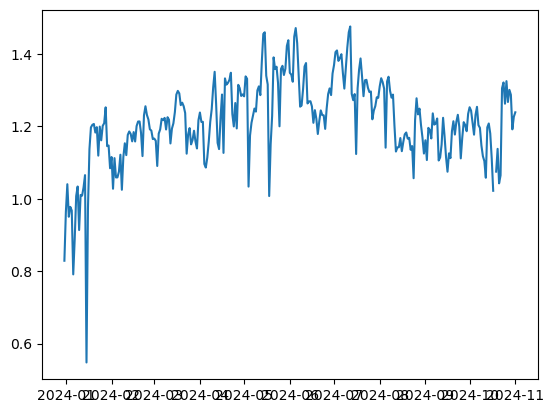

In [105]:
plt.plot(daily_pr.index, daily_pr)

#problem, we get a performance ratio greater than 1.... that's not supposed to happen! I think the pvlib model and our actual system have some slight discrepancy